# Statistic's Notebook
The purpose of this Notebook is to do statistic analyses of a simulation dataset

In [5]:
import os
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import seaborn as sns

sns.set_style('whitegrid')


## Import the dataset

In [55]:
# Target datasets
DATASETS = ["Dataset30.csv", "Dataset31.csv", "Dataset32.csv", "Dataset33.csv", "Dataset34.csv", "Dataset35.csv"]

# Compute the global dataset
df = pd.DataFrame()
for d in DATASETS:
    df_temp = pd.read_csv(d)
    df = pd.concat([df, df_temp])

print(df['PGAz_structure'])

0     0.659483
1     0.659483
2     0.659483
3     0.659483
4     0.659483
        ...   
39    3.769661
40    3.769661
41    3.769661
42    3.769661
43    3.769661
Name: PGAz_structure, Length: 264, dtype: float64


In [34]:
# -------------------------------
# Définition des paramètres et cibles
# -------------------------------
features = ["Lc_x", "f0", "angle"]  # Paramètres (variables explicatives)
targets = [
    'Peak_Sliding_Left', 'Peak_Uplift_Left',
    'Peak_Sliding_Bottom', 'Peak_Uplift_Bottom',
    'Peak_Sliding_Right', 'Peak_Uplift_Right',
    'PGDx_soil', 'PGDz_soil', 'PGDx_structure', 'PGDz_structure', 'PGD_input',
    'PGVx_soil', 'PGVz_soil', 'PGVx_structure', 'PGVz_structure', 'PGV_input',
    'PGAx_soil', 'PGAz_soil', 'PGAx_structure', 'PGAz_structure', 'PGA_input'
]  # Variables cibles à prédire

## Correlations between variables

Text(0.5, 1.0, 'Correlations between target variables')

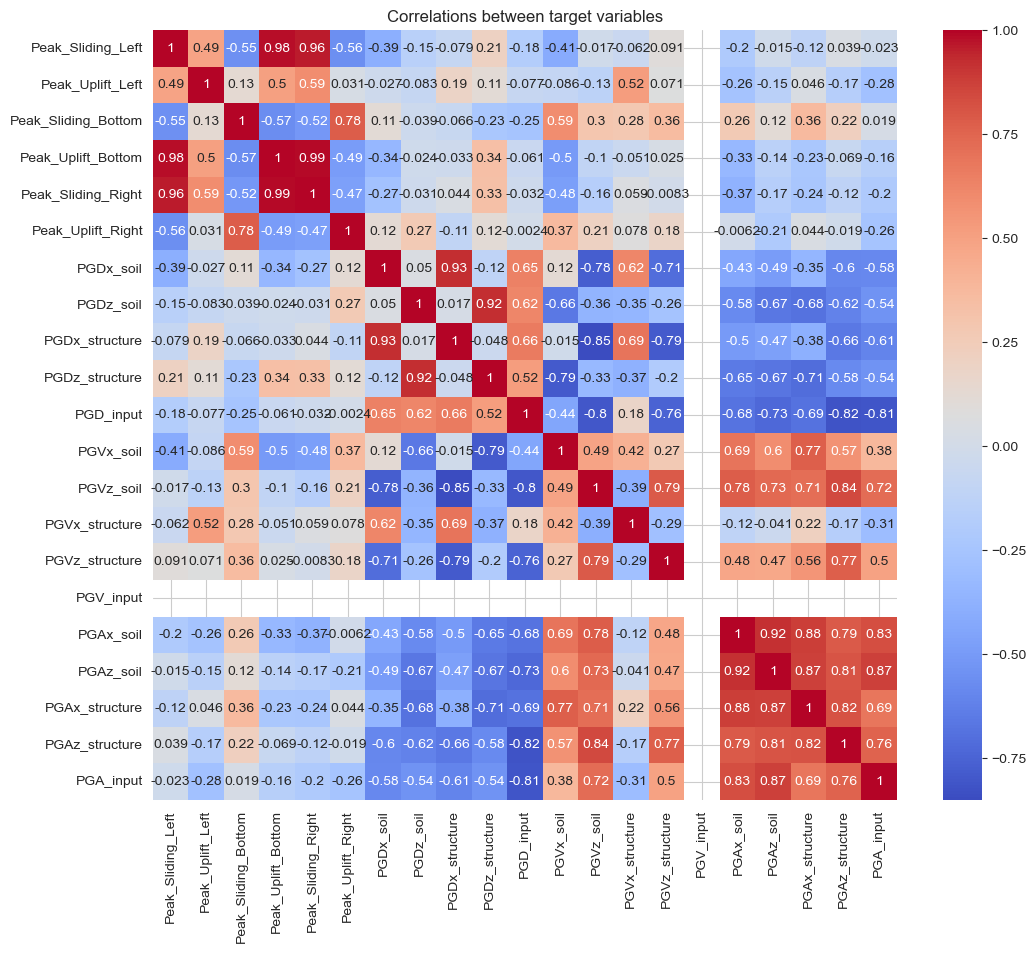

In [13]:
corr = df[targets].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlations between target variables")

## Joint Plot

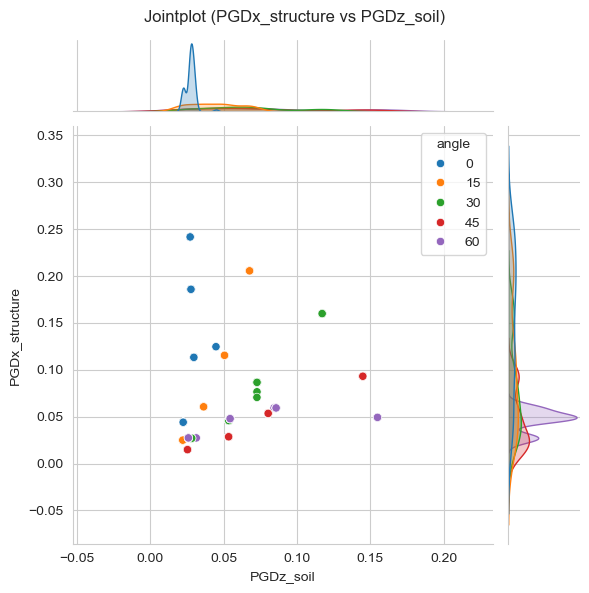

In [56]:
X_comp = 'PGDz_soil'
Y_comp = 'PGDx_structure'
color_comp = 'angle'

JP = sns.jointplot(data=df, x=X_comp, y=Y_comp, hue=color_comp, kind='scatter', palette='tab10')
JP.figure.suptitle(f"Jointplot ({Y_comp} vs {X_comp})")
JP.figure.tight_layout()
JP.figure.subplots_adjust(top = 0.93)



## Violin Box Plot

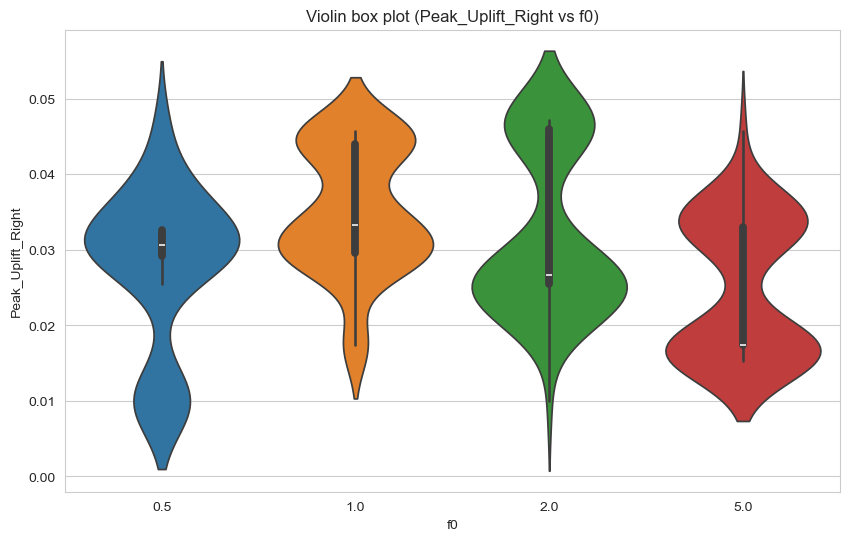

In [63]:
def show_violins(X_comp, Y_comp, color=None):
    fig, ax = plt.subplots(figsize=(10,6))
    legend='auto'
    if color is None:
        color = X_comp
        legend = False
    ax = sns.violinplot(data=df, x=X_comp, y=Y_comp, hue=color, palette='tab10', legend=legend)
    ax.set_title(f"Violin box plot ({Y_comp} vs {X_comp})")
    
X_comp = 'f0'
Y_comp = 'Peak_Uplift_Right'
color_comp = None
show_violins(X_comp, Y_comp, color_comp)



## Importance of each input parameter

In [17]:

X = df[features]

# -------------------------------
# Calcul de l’importance par permutation
# -------------------------------
importances_perm = {}

for target in targets:
    y = df[target]
    
    # Modèle de régression par forêt aléatoire
    model = RandomForestRegressor(n_estimators=300, random_state=0)
    model.fit(X, y)

    # Importance par permutation
    result = permutation_importance(
        model, X, y,
        n_repeats=100,
        random_state=0,
        scoring="r2"
    )
    
     # Importance brute
    importances = result.importances_mean

    # Normalisation : somme = 1
    importances_norm = importances / importances.sum()

    # Stocker l’importance normalisée
    importances_perm[target] = importances_norm

importances_df = pd.DataFrame(importances_perm, index=features)

C:\Users\t.guyonneau\AppData\Local\Temp\ipykernel_26928\3025940748.py:27: RuntimeWarning: invalid value encountered in divide
  importances_norm = importances / importances.sum()


<Figure size 1000x500 with 0 Axes>

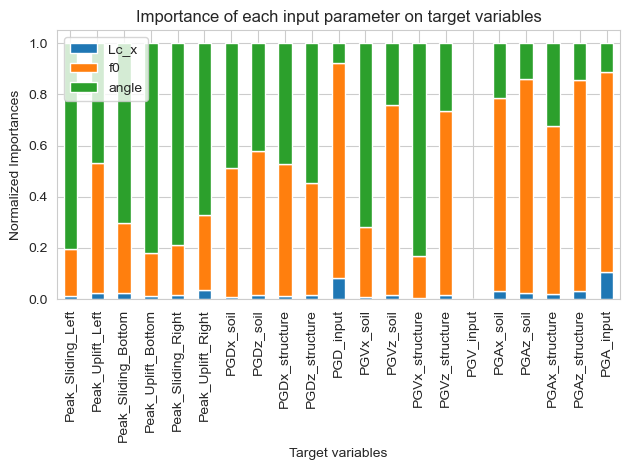

In [18]:
# -------------------------------
# Affichage des données
# -------------------------------
display_mode = 'bar'

fig = plt.figure(figsize=(10,5))
if display_mode=='heatmap':
    ax = fig.add_subplot(1,1,1)
    ax = sns.heatmap(importances_df, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={"label": "Importance"})
    ax.set_title("Normalized importances of input parameters (Random Forest Estimator)")
    ax.set_xlabel("Target variables")
    ax.set_ylabel("Input parameters")
elif display_mode=='bar':
    xlabel = "Target variables"
    ylabel = "Normalized Importances"
    title = "Importance of each input parameter on target variables"
    ax = importances_df.T.plot(kind='bar', stacked='True', xlabel=xlabel, ylabel=ylabel, title=title)
    plt.tight_layout()
else:
    raise Exception("Undefined display_mode")

## ECDF Plot

Text(0.5, 1.0, 'Proportion of simulations below a ratio value')

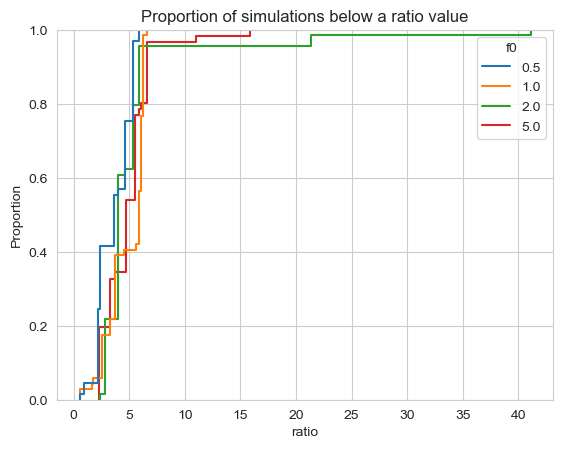

In [65]:
df['ratio'] = df['PGAx_soil'] / df['PGA_input']
X_comp = 'ratio'
color_comp = 'f0'
ax = sns.ecdfplot(data=df, x=X_comp, hue=color_comp, palette='tab10')

# ratios = {
#     'Ratio0': df[df['f0'] == 0.5]['PGAx'].to_numpy() / 0.13,
#     'Ratio1': df[df['f0'] == 1.0]['PGAx'].to_numpy() / 0.27,
#     'Ratio2': df[df['f0'] == 2.0]['PGAx'].to_numpy() / 0.54,
#     'Ratio3': df[df['f0'] == 5.0]['PGAx'].to_numpy() / 1.35,
# }



#sns.ecdfplot(data=ratios, x='Ratio0', palette='tab10')
# sns.ecdfplot(data=ratios, x='Ratio1', palette='tab10')
# sns.ecdfplot(data=ratios, x='Ratio2', palette='tab10')
# sns.ecdfplot(data=ratios, x='Ratio3', palette='tab10')

PGA_Input = [1.35, 0.54, 0.27, 0.13]
amplification = 5
lines = ax.get_lines()
# for i in range(len(lines)):
#     x, y = lines[i].get_xdata(), lines[i].get_ydata()
#     index = (np.abs(x-amplification*PGA_Input[i])).argmin()
#     ax.scatter(x[index], y[index], marker='o', c='black')
ax.set_title(f"Proportion of simulations below a {X_comp} value")

## Scatter Plot

Text(0.5, 1.0, 'Peak_Sliding_Right vs PGAx_soil')

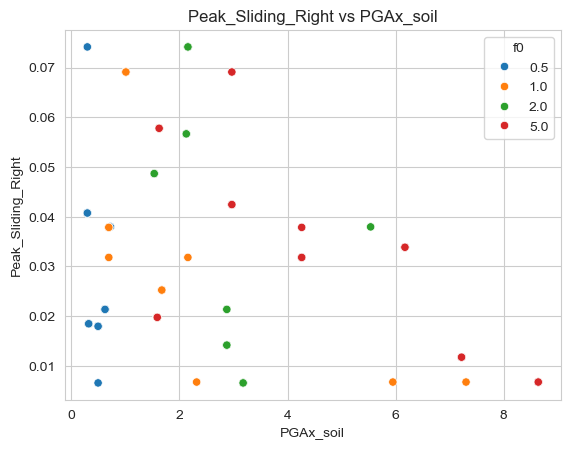

In [28]:
fig, ax = plt.subplots()
X_comp = "PGAx_soil"
Y_comp = "Peak_Sliding_Right"
color_comp = 'f0'

ax = sns.scatterplot(data=df, x=X_comp, y=Y_comp, hue=color_comp, palette='tab10')
ax.set_title(f"{Y_comp} vs {X_comp}")
# ax.set_xlim(7.2,7.3)
# ax.set_ylim(0.01,0.015)


## Regression Plot

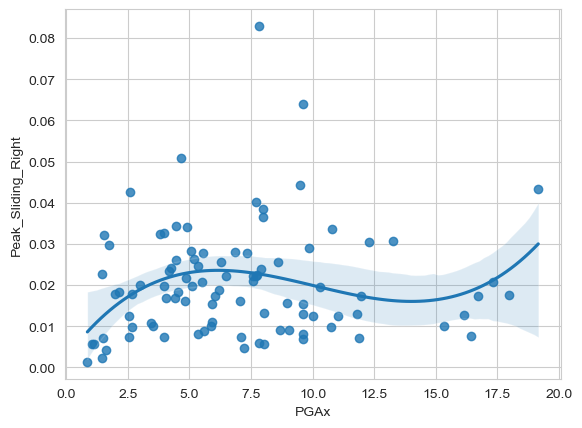

In [ ]:
df_red = df[df['Lc_x']==40]
X_comp = 'PGAx'
Y_comp = 'Peak_Sliding_Right'

ax = sns.regplot(data=df_red, x=X_comp, y=Y_comp, order=3)

In [53]:
from ast import literal_eval

x = df['freq'].iloc[0]     # Exemple : "[1.0, 2.0, 3.0]"
#arr = np.array(x[1:-1].split(), dtype=float)

# x = df['freq'].iloc[0]
# y = df['TF'][0]
print(len(x[1:-1]))


94
